In [28]:
data1 = [72, 51, 146, 30, 28, 88, 92, 47, 52, 68, 80, 34, 28, 105, 76, 93, 55, 40, 62, 37, 88, 30, 122, 46, 35, 29, 77, 40, 71, 57]
data2 = [88, 130, 255, 56, 0, 38, 167, 188, 132, 147, 78, 80, 40, 170, 280, 46, 174, 182, 75, 89, 103, 230, 380, 57, 55, 90, 96, 102, 78, 69, 53, 160, 195, 245, 60, 94, 145, 115, 225, 71]

{'Q1': 37, 'Median': 56.0, 'Q3': 80, 'Lower whisker': 28, 'Upper whisker': 144.5, 'Outliers': array([146])}


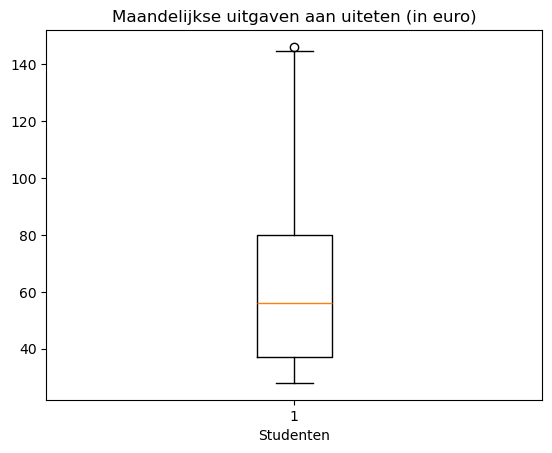

In [92]:
import numpy as np
import matplotlib.pyplot as plt

def custom_boxplot(data, title, xlabel, ax=None):
    """
    Create a boxplot where:
    1. The median is the mean of the two middle values for even n.
    2. Q1 and Q3 are medians of the lower and upper halves (exclusive of the overall median if n is odd).
    3. Whiskers extend to the most extreme points within 1.5 * IQR from Q1 and Q3.
    """
    data = np.sort(np.asarray(data))
    n = len(data)

    # --- Median ---
    if n % 2 == 0:
        median = np.mean(data[(n//2 - 1):(n//2 + 1)])
        lower_half = data[:(n//2)]
        upper_half = data[(n//2):]
    else:
        median = data[n//2]
        lower_half = data[:(n//2)]
        upper_half = data[(n//2 + 1):]

    # --- Q1 and Q3 ---
    def median_custom(x):
        m = len(x)
        if m % 2 == 0:
            return np.mean(x[(m//2 - 1):(m//2 + 1)])
        else:
            return x[m//2]

    Q1 = median_custom(lower_half)
    Q3 = median_custom(upper_half)
    IQR = Q3 - Q1

    # --- Whiskers ---
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    lower_whisker = max(lower_bound, np.min(data))
    upper_whisker = min(upper_bound, np.max(data))

    # --- Outliers ---
    outliers = data[(data < lower_whisker) | (data > upper_whisker)]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots()

    ax.bxp([{
        'med': median,
        'q1': Q1,
        'q3': Q3,
        'whislo': lower_whisker,
        'whishi': upper_whisker,
        'fliers': outliers
    }], showfliers=True)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    return {'Q1': Q1, 'Median': median, 'Q3': Q3,
            'Lower whisker': lower_whisker, 'Upper whisker': upper_whisker,
            'Outliers': outliers}

# Example usage
# data = [25, 32, 45, 60, 65, 66, 70, 75, 80, 82]
result = custom_boxplot(data1, title="Maandelijkse uitgaven aan uiteten (in euro)", xlabel = "Studenten")
print(result)
plt.show()


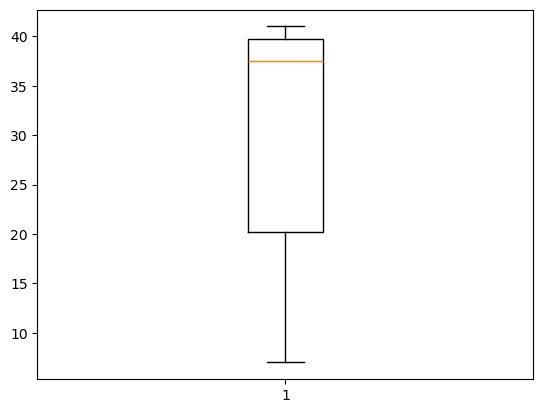

In [60]:
example = [7, 15, 36, 39, 40, 41]
bp = plt.boxplot([example])
bp["boxes"]